## Importations

In [136]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)

In [137]:
DATA_PROC_PATH = Path("../data/processed")                                                                   
   
X_train = pd.read_csv(DATA_PROC_PATH / "X_train.csv")                                                        
X_test  = pd.read_csv(DATA_PROC_PATH / "X_test.csv")
y_train = pd.read_csv(DATA_PROC_PATH / "y_train.csv").squeeze()
y_test  = pd.read_csv(DATA_PROC_PATH / "y_test.csv").squeeze()

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_train : {y_train.shape}  — churn rate : {y_train.mean()*100:.1f}%")
print(f"y_test  : {y_test.shape}   — churn rate : {y_test.mean()*100:.1f}%")

X_train : (8000, 48)
X_test  : (2000, 48)
y_train : (8000,)  — churn rate : 10.2%
y_test  : (2000,)   — churn rate : 10.2%


## Construction des modèles

In [138]:
ratio = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

# Modèles à construire
models = {
    "Régression Logistique": LogisticRegression(class_weight='balanced',max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(class_weight='balanced_subsample',n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6, scale_pos_weight=ratio, random_state=42, eval_metric='logloss')
}

## Entrainement

In [139]:
# Entraîner les modèles et stocker leurs probabilités
model_results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_proba = model.predict_proba(X_test)[:, 1]  # Probabilité pour la classe positive
    model_results[name] = y_proba

## Evaluation

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Initialiser une liste pour stocker les résultats
results = []

# Comparer chaque modèle déjà entraîné
for name, model in models.items():
    # Obtenir les prédictions et probabilités
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]  # Probabilité pour la classe positive
    
    # Calcul des métriques
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    
    # Ajouter les résultats à la liste
    results.append({
        "Modèle": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "AUC": auc
    })

# Convertir les résultats en DataFrame
results_df = pd.DataFrame(results)

# Afficher les résultats
print("Comparaison des modèles :")
print(results_df)


Comparaison des modèles :
                  Modèle  Accuracy  Precision    Recall  F1-Score       AUC
0  Régression Logistique    0.6725   0.188105  0.666667  0.293420  0.736009
1          Random Forest    0.8980   0.000000  0.000000  0.000000  0.798704
2                XGBoost    0.8150   0.274457  0.495098  0.353147  0.779791


c:\Users\youne\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


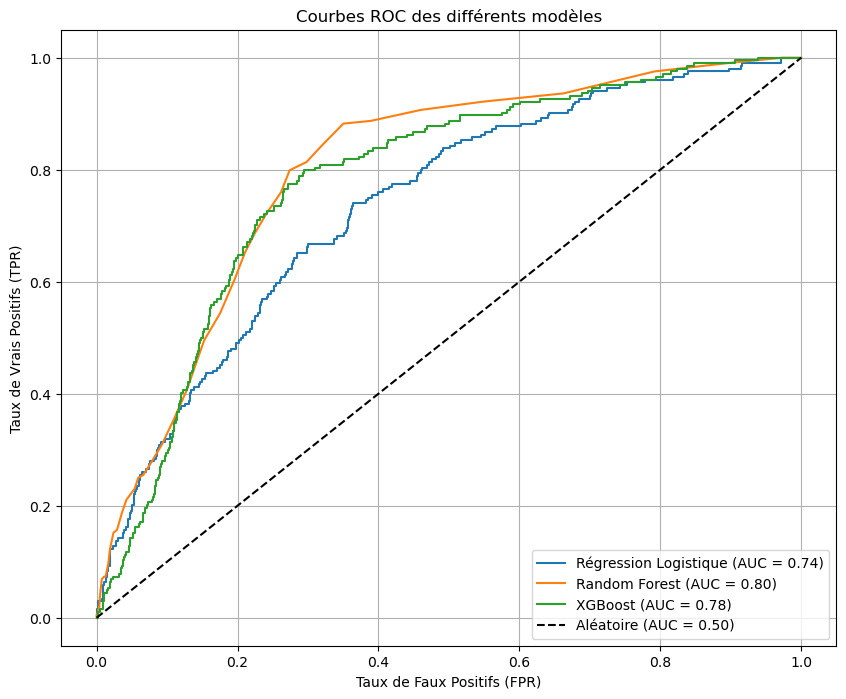

In [141]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Tracer les courbes ROC
plt.figure(figsize=(10, 8))
for name, y_proba in model_results.items():
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.2f})")

# Ajouter des détails au graphique
plt.plot([0, 1], [0, 1], 'k--', label="Aléatoire (AUC = 0.50)")
plt.xlabel("Taux de Faux Positifs (FPR)")
plt.ylabel("Taux de Vrais Positifs (TPR)")
plt.title("Courbes ROC des différents modèles")
plt.legend(loc="lower right")
plt.grid()
plt.show()


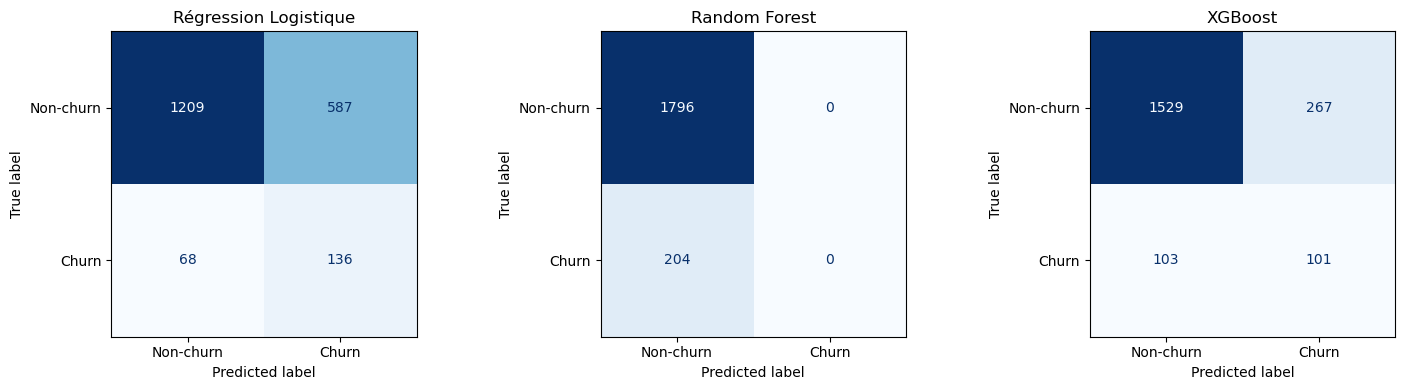

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-churn", "Churn"]).plot(ax=ax, cmap="Blues", colorbar=False)

    ax.set_title(name)

plt.tight_layout()
plt.show()

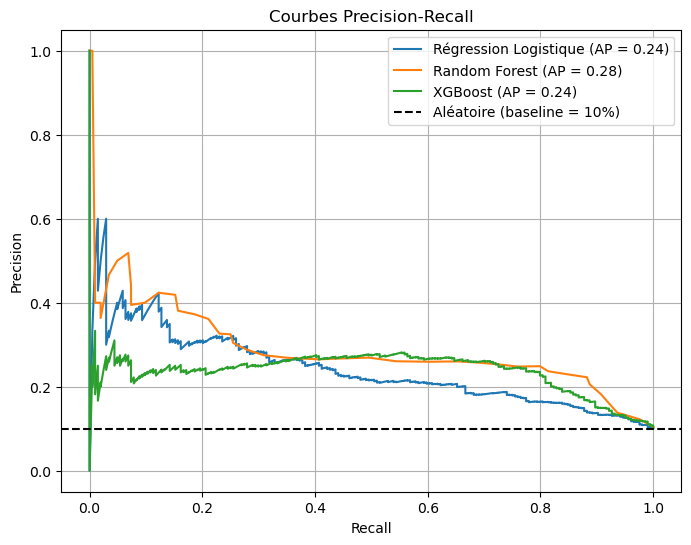

In [143]:
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(8, 6))
for name, y_proba in model_results.items():
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    ap = average_precision_score(y_test, y_proba)
    plt.plot(recall, precision, label=f"{name} (AP = {ap:.2f})")

plt.axhline(y=0.10, color='k', linestyle='--', label="Aléatoire (baseline = 10%)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Courbes Precision-Recall")
plt.legend()
plt.grid()
plt.show()

In [144]:
# Exemple sur le meilleur modèle (Régression Logistique a le meilleur recall)
y_proba_lr = model_results["Régression Logistique"]

print("Comparaison des seuils — Régression Logistique\n")
print(f"{'Seuil':>8}  {'Precision':>10}  {'Recall':>8}  {'F1':>8}")
for threshold in [0.3, 0.4, 0.5, 0.6]:
    y_pred_t = (y_proba_lr >= threshold).astype(int)
    p = precision_score(y_test, y_pred_t, zero_division=0)
    r = recall_score(y_test, y_pred_t)
    f = f1_score(y_test, y_pred_t, zero_division=0)
    print(f"{threshold:>8.1f}  {p:>10.3f}  {r:>8.3f}  {f:>8.3f}")

Comparaison des seuils — Régression Logistique

   Seuil   Precision    Recall        F1
     0.3       0.133     0.922     0.233
     0.4       0.163     0.819     0.271
     0.5       0.188     0.667     0.293
     0.6       0.230     0.441     0.303


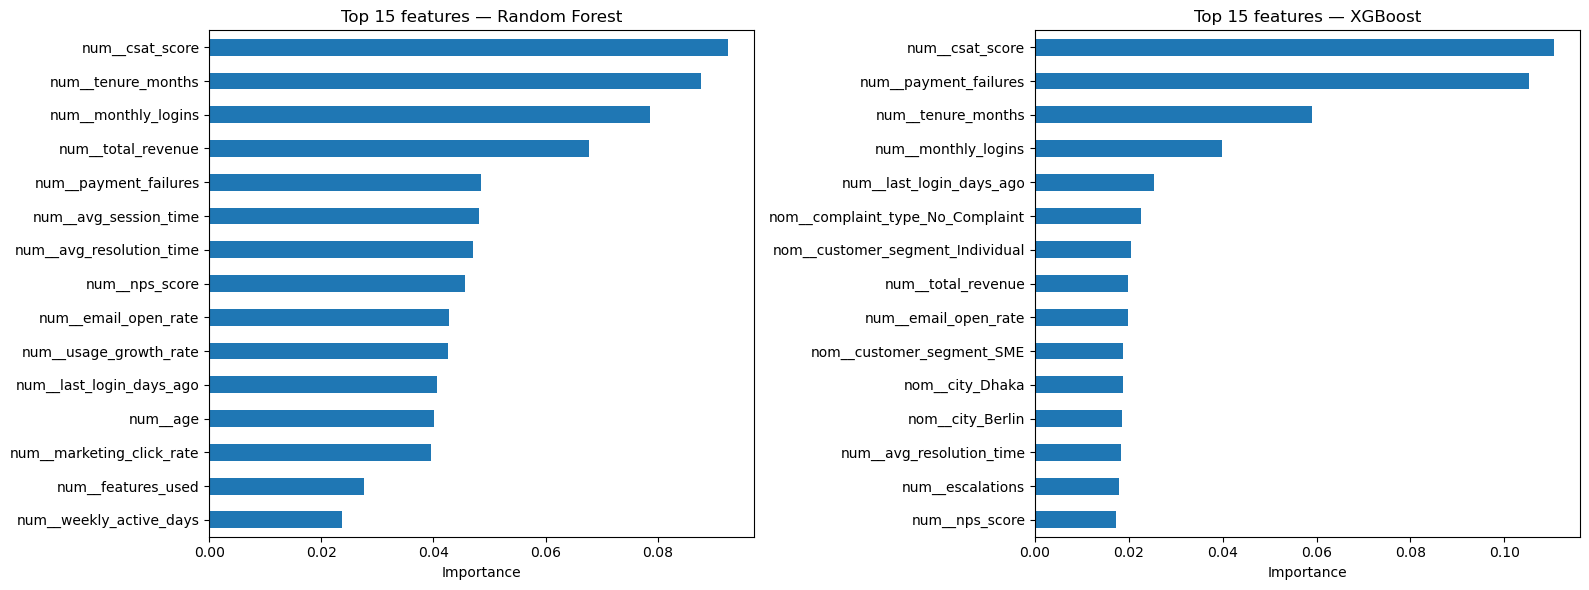

In [145]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, name in zip(axes, ["Random Forest", "XGBoost"]):
    model = models[name]
    importances = pd.Series(model.feature_importances_, index=X_train.columns)
    importances.nlargest(15).sort_values().plot(kind='barh', ax=ax)
    ax.set_title(f"Top 15 features — {name}")
    ax.set_xlabel("Importance")

plt.tight_layout()
plt.show()